In [1]:
# =========================================================
# 1. Daten laden
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/corpus_activation_results.csv")

# optional
try:
    custom = pd.read_csv("/content/custom_parser_activation_results.csv")
    df = pd.concat([df, custom], ignore_index=True)
except:
    pass

df = df.dropna(subset=["turnover", "q", "mse_log"]).copy()

print("Datensatz:", len(df))
print(df.head())

Datensatz: 134
   galaxy survey  quality_tier  n_points_raw  n_points_used  turnover  \
0  D564-8  SPARC             1             6              6  0.703646   
1  D631-7  SPARC             1            16             13  2.287700   
2  DDO064  SPARC             1            14             14  0.738585   
3  DDO154  SPARC             1            12             12  1.658802   
4  DDO161  SPARC             1            31             31 -0.167393   

   curvature_std  curvature_max             q          A0   mse_log  \
0       1.139262       2.745618  2.507201e-07  150.365640  0.016165   
1       7.721405      16.009613  9.527608e-05  385.626727  0.030921   
2       9.134049      16.800132  2.858191e-07  532.607957  0.023032   
3       3.001291       6.890526  9.010751e-06  374.112473  0.028349   
4      21.475127      72.140143  9.563362e-09  197.095245  0.297768   

   r_min_kpc  r_max_kpc  vobs_max_kms  distance_mpc  inc_deg  m2l_disk  \
0       0.51       3.07          25.0        

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

save_path = "/content/drive/MyDrive/galaxy_field_project_2/figures"
os.makedirs(save_path, exist_ok=True)

print("Save path:", save_path)
print("Exists:", os.path.isdir(save_path))
print("Current files:", os.listdir(save_path))

Mounted at /content/drive
Save path: /content/drive/MyDrive/galaxy_field_project_2/figures
Exists: True
Current files: ['activation_schematic.png']


In [3]:
def savefig(name: str):
    file_path = os.path.join(save_path, f"{name}.png")
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    print("Saved:", file_path)

In [4]:
plt.rcParams.update({
    "figure.figsize": (8, 6),
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

Saved: /content/drive/MyDrive/galaxy_field_project_2/figures/activation_schematic.png


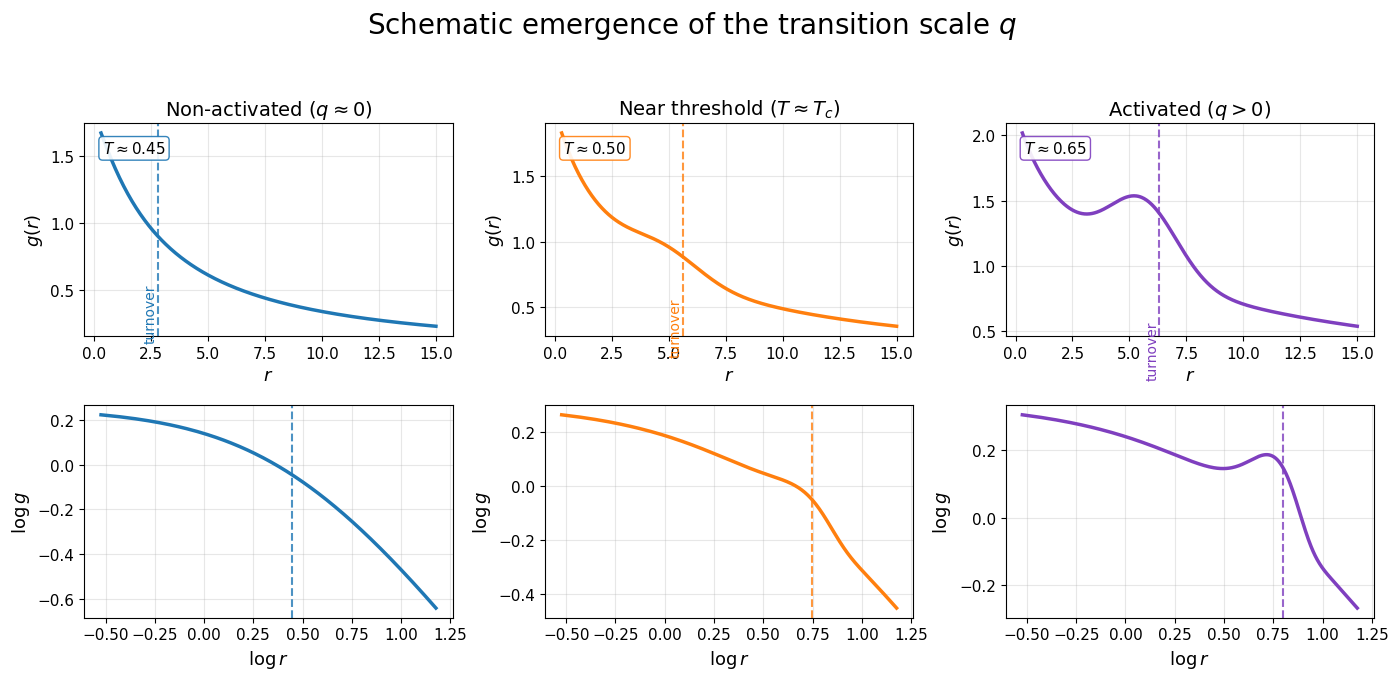

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================================================
# Save-Funktion
# =========================================================
save_path = "/content/drive/MyDrive/galaxy_field_project_2/figures"
os.makedirs(save_path, exist_ok=True)

def savefig(name: str):
    file_path = os.path.join(save_path, f"{name}.png")
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    print("Saved:", file_path)

# =========================================================
# Schematische Profile
# =========================================================
r = np.linspace(0.3, 15, 400)

# Nicht aktiviert: glatt, monoton
g_non = 1.8 / (1 + (r/2.8)**1.15)

# Übergang: Schulter / beginnender Umschlag
g_trans = 2.0 / (1 + (r/3.2)**1.0) + 0.18 * np.exp(-0.5*((r-4.8)/1.6)**2)

# Aktiviert: klarer innerer Überschuss + deutlicher Turnover
g_act = 2.2 / (1 + (r/4.3)**0.9) + 0.55 * np.exp(-0.5*((r-5.6)/1.5)**2)

profiles = [
    ("Non-activated ($q\\approx 0$)", g_non, "#1f77b4"),
    ("Near threshold ($T\\approx T_c$)", g_trans, "#ff7f0e"),
    ("Activated ($q>0$)", g_act, "#7f3fbf"),
]

# =========================================================
# Hilfsfunktion: Turnover grob markieren
# =========================================================
def turnover_info(r, g):
    log_r = np.log10(r)
    log_g = np.log10(g)
    d1 = np.gradient(log_g, log_r)

    inner_n = max(2, len(d1)//3)
    outer_n = max(2, len(d1)//3)

    s_in = np.mean(d1[:inner_n])
    s_out = np.mean(d1[-outer_n:])
    T = s_in - s_out

    d2 = np.gradient(d1, log_r)
    idx = np.argmax(np.abs(d2))
    r_turn = r[idx]
    return T, r_turn

# =========================================================
# Stil
# =========================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# =========================================================
# Abbildung
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for j, (title, g, color) in enumerate(profiles):
    T, r_turn = turnover_info(r, g)

    # obere Reihe: g(r)
    ax = axes[0, j]
    ax.plot(r, g, lw=2.5, color=color)
    ax.axvline(r_turn, ls="--", lw=1.5, color=color, alpha=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$g(r)$")
    ax.grid(True, alpha=0.3)

    ax.text(
        0.05, 0.92,
        rf"$T \approx {T:.2f}$",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color, alpha=0.9)
    )

    ax.text(
        r_turn, ax.get_ylim()[1]*0.06,
        "turnover",
        rotation=90, va="bottom", ha="right",
        color=color, fontsize=10
    )

    # untere Reihe: log g vs log r
    ax2 = axes[1, j]
    ax2.plot(np.log10(r), np.log10(g), lw=2.5, color=color)
    ax2.axvline(np.log10(r_turn), ls="--", lw=1.5, color=color, alpha=0.8)
    ax2.set_xlabel(r"$\log r$")
    ax2.set_ylabel(r"$\log g$")
    ax2.grid(True, alpha=0.3)

# Gesamttitel + Layout
fig.suptitle("Schematic emergence of the transition scale $q$", fontsize=20, y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.94])

# speichern
savefig("activation_schematic")

plt.show()

Lade: /content/drive/MyDrive/galaxy_field_project_2/activation_threshold_analysis.csv
Lade: /content/drive/MyDrive/galaxy_field_project_2/corpus_activation_results.csv
Lade: /content/drive/MyDrive/galaxy_field_project_2/custom_parser_activation_results.csv
Lade JSON: /content/rotation_curve_corpus_v7.json
Gewählte Beispielgalaxien:

Non-activated   NGC7331      | survey=SPARC | T=7.904 | q=20 | mse=0.0881
Near threshold  NGC0055      | survey=SPARC | T=3.800 | q=0.0277 | mse=0.1898
Activated       UGC02916     | survey=SPARC | T=5.090 | q=2.97 | mse=0.4585

Gespeichert: /content/drive/MyDrive/galaxy_field_project_2/figures/activation_examples_fixed_galaxies.png


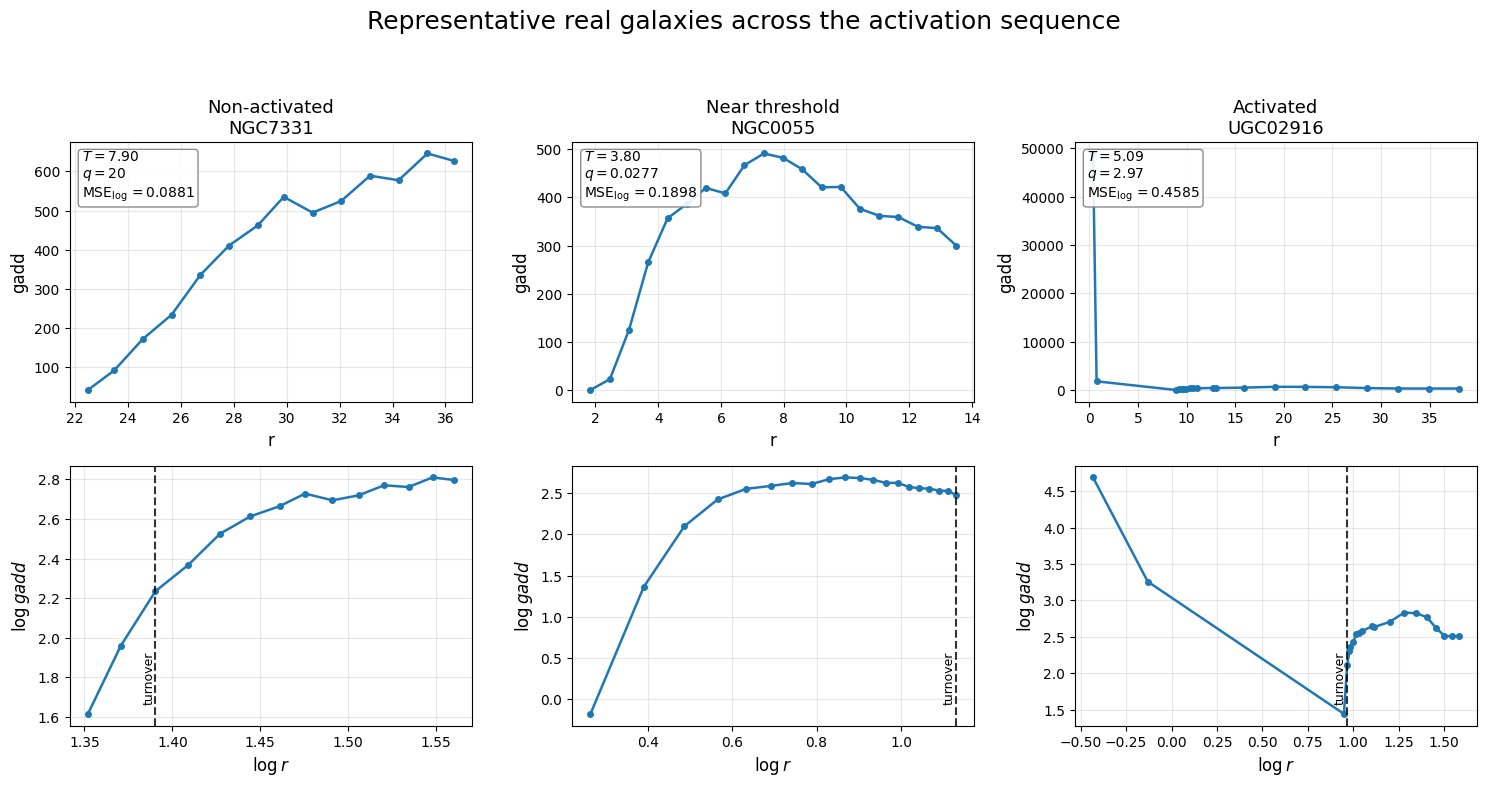

In [7]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 0. Basisordner
# =========================================================
BASE = "/content/drive/MyDrive/galaxy_field_project_2"
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(FIGDIR, exist_ok=True)

# =========================================================
# 1. Fest gewählte Beispielgalaxien
# =========================================================
GAL_NON   = "NGC7331"
GAL_TRANS = "NGC0055"
GAL_ACT   = "UGC02916"

selected = [
    ("Non-activated", GAL_NON),
    ("Near threshold", GAL_TRANS),
    ("Activated", GAL_ACT),
]

# =========================================================
# 2. Hilfsfunktionen zum Laden
# =========================================================
def load_csv_prefer_drive(filename):
    p1 = os.path.join(BASE, filename)
    p2 = os.path.join("/content", filename)
    if os.path.exists(p1):
        print("Lade:", p1)
        return pd.read_csv(p1)
    if os.path.exists(p2):
        print("Lade:", p2)
        return pd.read_csv(p2)
    raise FileNotFoundError(filename)

# =========================================================
# 3. Ergebnisdateien laden
# =========================================================
thr = load_csv_prefer_drive("activation_threshold_analysis.csv")
corpus = load_csv_prefer_drive("corpus_activation_results.csv")

try:
    custom = load_csv_prefer_drive("custom_parser_activation_results.csv")
except:
    custom = pd.DataFrame()

res = pd.concat([corpus, custom], ignore_index=True, sort=False)
res = res.drop_duplicates(subset=["galaxy"], keep="first")

# =========================================================
# 4. Corpus JSON laden
# =========================================================
json_candidates = [
    os.path.join(BASE, "rotation_curve_corpus_v7.json"),
    "/content/rotation_curve_corpus_v7.json"
]

json_path = None
for p in json_candidates:
    if os.path.exists(p):
        json_path = p
        break

if json_path is None:
    raise FileNotFoundError("rotation_curve_corpus_v7.json nicht gefunden")

print("Lade JSON:", json_path)

with open(json_path, "r", encoding="utf-8") as f:
    corpus_json = json.load(f)

galaxies = corpus_json["galaxies"]

# =========================================================
# 5. Hilfsfunktionen
# =========================================================
def safe_num(s):
    return pd.to_numeric(s, errors="coerce")

def get_galaxy_df(gal_name):
    for gal in galaxies:
        if gal.get("galaxy") == gal_name:
            data = gal.get("data", [])
            if isinstance(data, list) and len(data) > 0:
                return pd.DataFrame(data), gal
    return None, None

def extract_profile(df):
    cols = df.columns.tolist()

    # SPARC-artig -> gadd
    if all(c in cols for c in ["Rad", "Vobs", "Vgas", "Vdisk", "Vbul"]):
        r = safe_num(df["Rad"]).values
        vobs = safe_num(df["Vobs"]).values
        vgas = safe_num(df["Vgas"]).values
        vdisk = safe_num(df["Vdisk"]).values
        vbul = safe_num(df["Vbul"]).values

        mask = (
            np.isfinite(r) & np.isfinite(vobs) & np.isfinite(vgas) &
            np.isfinite(vdisk) & np.isfinite(vbul) &
            (r > 0) & (vobs > 0)
        )
        r = r[mask]
        vobs = vobs[mask]
        vgas = vgas[mask]
        vdisk = vdisk[mask]
        vbul = vbul[mask]

        gobs = (vobs**2) / r
        gbar = (np.sign(vgas) * vgas**2 + vdisk**2 + vbul**2) / r
        y = gobs - gbar

        ok = np.isfinite(y) & (y > 0)
        return r[ok], y[ok], "gadd"

    # THINGS / LITTLE THINGS -> geff
    rad_col = "Rad" if "Rad" in cols else None
    vel_col = None
    for c in ["Vrot", "Vc", "Vobs", "Vr"]:
        if c in cols:
            vel_col = c
            break

    if rad_col is not None and vel_col is not None:
        r = safe_num(df[rad_col]).values
        v = safe_num(df[vel_col]).values
        ok = np.isfinite(r) & np.isfinite(v) & (r > 0) & (v > 0)
        r = r[ok]
        v = v[ok]
        y = (v**2) / r
        return r, y, "geff"

    return None, None, None

def get_result_row(gal_name):
    rr = res[res["galaxy"] == gal_name]
    if len(rr) == 0:
        return None
    return rr.iloc[0]

# =========================================================
# 6. Übersicht
# =========================================================
print("Gewählte Beispielgalaxien:\n")
for label, gname in selected:
    rr = get_result_row(gname)
    if rr is None:
        print(f"{label:15s} {gname:12s} -> NICHT in Ergebnisdateien gefunden")
    else:
        print(
            f"{label:15s} {gname:12s} | survey={rr.get('survey', 'n/a')} "
            f"| T={rr.get('turnover', np.nan):.3f} "
            f"| q={rr.get('q', np.nan):.3g} "
            f"| mse={rr.get('mse_log', np.nan):.4f}"
        )

# =========================================================
# 7. Plot-Stil
# =========================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# =========================================================
# 8. Plot
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for j, (label, gname) in enumerate(selected):
    df_gal, meta = get_galaxy_df(gname)
    row = get_result_row(gname)

    if df_gal is None or row is None:
        axes[0, j].text(0.5, 0.5, f"{gname}\nnot found", ha="center", va="center")
        axes[1, j].text(0.5, 0.5, f"{gname}\nnot found", ha="center", va="center")
        continue

    r, y, yname = extract_profile(df_gal)
    if r is None or len(r) < 4:
        axes[0, j].text(0.5, 0.5, f"{gname}\nno usable profile", ha="center", va="center")
        axes[1, j].text(0.5, 0.5, f"{gname}\nno usable profile", ha="center", va="center")
        continue

    # obere Reihe
    ax = axes[0, j]
    ax.plot(r, y, "o-", ms=4, lw=1.8)
    ax.set_title(f"{label}\n{gname}", fontsize=13)
    ax.set_xlabel("r")
    ax.set_ylabel(yname)
    ax.grid(True, alpha=0.3)

    txt = (
        rf"$T={row['turnover']:.2f}$" + "\n" +
        rf"$q={row['q']:.3g}$" + "\n" +
        rf"$\mathrm{{MSE}}_{{\log}}={row['mse_log']:.4f}$"
    )
    ax.text(
        0.03, 0.97, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.5", alpha=0.9)
    )

    # untere Reihe
    ax2 = axes[1, j]
    ok = (r > 0) & (y > 0)
    lr = np.log10(r[ok])
    ly = np.log10(y[ok])
    ax2.plot(lr, ly, "o-", ms=4, lw=1.8)
    ax2.set_xlabel(r"$\log r$")
    ax2.set_ylabel(rf"$\log {yname}$")
    ax2.grid(True, alpha=0.3)

    # Turnover-Markierung
    if len(lr) >= 5:
        d1 = np.gradient(ly, lr)
        d2 = np.gradient(d1, lr)
        idx = np.argmax(np.abs(d2))
        ax2.axvline(lr[idx], ls="--", lw=1.5, color="black", alpha=0.8)
        y0, y1 = ax2.get_ylim()
        ax2.text(
            lr[idx],
            y0 + 0.08*(y1-y0),
            "turnover",
            rotation=90,
            va="bottom",
            ha="right",
            fontsize=9
        )

# Titel und Layout
fig.suptitle("Representative real galaxies across the activation sequence", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94])

# Speichern im figures-Ordner
out = os.path.join(FIGDIR, "activation_examples_fixed_galaxies.png")
fig.savefig(out, dpi=300, bbox_inches="tight")
print("\nGespeichert:", out)

plt.show()

Datensatz: 179
T_c: 4.33732349128945
Gespeichert: /content/drive/MyDrive/galaxy_field_project_2/figures/q_vs_turnover.png


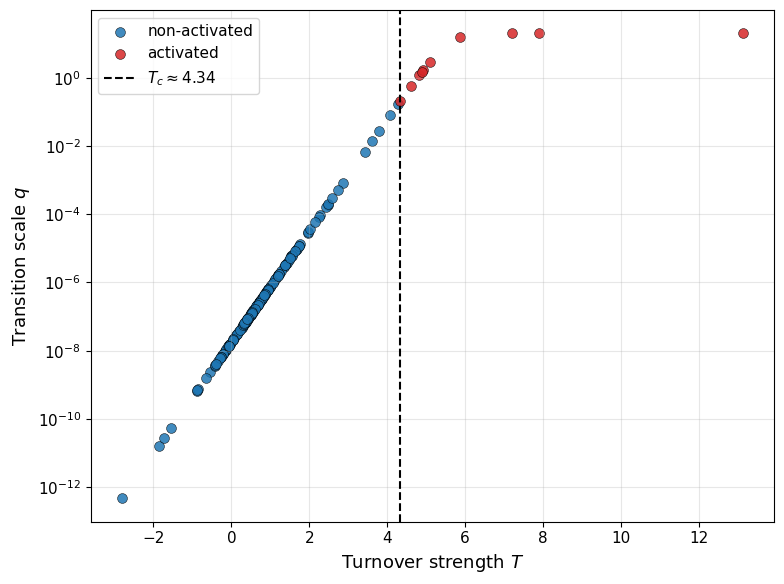

In [9]:
# =========================================================
# q vs Turnover Plot (Paper-ready)
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Pfade
# =========================================================
BASE = "/content/drive/MyDrive/galaxy_field_project_2"
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(FIGDIR, exist_ok=True)

# =========================================================
# 2. Daten laden
# =========================================================
file_path = os.path.join(BASE, "activation_threshold_analysis.csv")
if not os.path.exists(file_path):
    file_path = "/content/activation_threshold_analysis.csv"

thr = pd.read_csv(file_path)
thr = thr.dropna(subset=["turnover", "q"]).copy()

print("Datensatz:", len(thr))

# =========================================================
# 3. Tc bestimmen
# =========================================================
if "regime" in thr.columns:
    activated = thr[thr["regime"] == "activated"]
    Tc = activated["turnover"].min()
else:
    Tc = np.nan

print("T_c:", Tc)

# =========================================================
# 4. Plot-Stil
# =========================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

color_map = {
    "non_activated": "#1f77b4",
    "activated": "#d62728",
    "transition": "#ff7f0e"
}

# =========================================================
# 5. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))

if "regime" in thr.columns:
    for reg in ["non_activated", "transition", "activated"]:
        sub = thr[thr["regime"] == reg]
        if len(sub) == 0:
            continue

        ax.scatter(
            sub["turnover"], sub["q"],
            s=50,
            alpha=0.85,
            label=reg.replace("_", "-"),
            color=color_map.get(reg, "#333333"),
            edgecolor="black",
            linewidth=0.4
        )
else:
    ax.scatter(
        thr["turnover"], thr["q"],
        s=50,
        alpha=0.85,
        color="#1f77b4",
        edgecolor="black",
        linewidth=0.4
    )

# Tc Linie
if np.isfinite(Tc):
    ax.axvline(
        Tc,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=rf"$T_c \approx {Tc:.2f}$"
    )

# Achsen
ax.set_xlabel(r"Turnover strength $T$")
ax.set_ylabel(r"Transition scale $q$")
ax.set_yscale("log")

ax.grid(True, alpha=0.3)
ax.legend(frameon=True)

plt.tight_layout()

# =========================================================
# 6. Speichern
# =========================================================
out = os.path.join(FIGDIR, "q_vs_turnover.png")
fig.savefig(out, dpi=300, bbox_inches="tight")

print("Gespeichert:", out)

plt.show()

df_core: (3011, 11)
activation file: (179, 22)
Nach Merge: (2686, 14)
regime
non_activated    2363
activated         323
Name: count, dtype: int64
Verwendbare Punkte: 2686

Globaler MDAR-Fit
Slope = 0.6675564000441815
Intercept = 1.4192359883740393
Median |Residuum| = 0.08994216985026737

Gespeichert: /content/drive/MyDrive/galaxy_field_project_2/figures/mdar_regimes.png


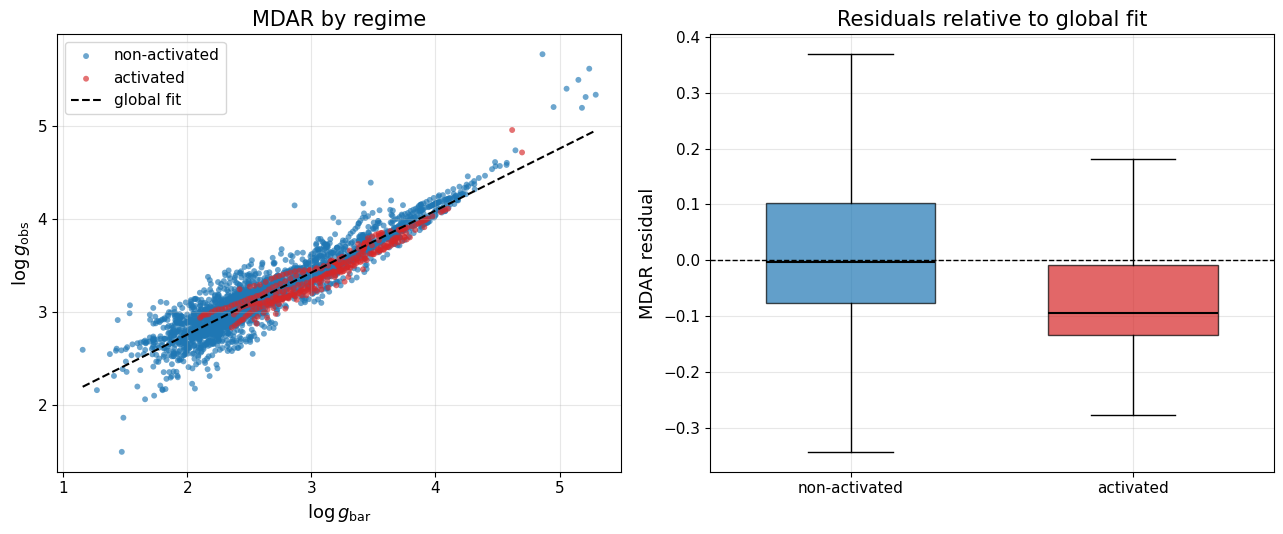

In [10]:
# =========================================================
# MDAR by dynamical regime (Paper-ready)
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Pfade
# =========================================================
BASE = "/content/drive/MyDrive/galaxy_field_project_2"
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(FIGDIR, exist_ok=True)

# =========================================================
# 2. Dateien laden
# =========================================================
core_path = os.path.join(BASE, "df_core.csv")
thr_path  = os.path.join(BASE, "activation_threshold_analysis.csv")

if not os.path.exists(core_path):
    core_path = "/content/df_core.csv"
if not os.path.exists(thr_path):
    thr_path = "/content/activation_threshold_analysis.csv"

df_core = pd.read_csv(core_path)
thr = pd.read_csv(thr_path)

print("df_core:", df_core.shape)
print("activation file:", thr.shape)

# =========================================================
# 3. Regime-Information übernehmen
# =========================================================
keep_cols = [c for c in ["galaxy", "regime", "q", "turnover"] if c in thr.columns]
reg = thr[keep_cols].drop_duplicates(subset=["galaxy"]).copy()

df = df_core.merge(reg, on="galaxy", how="inner")
print("Nach Merge:", df.shape)
print(df["regime"].value_counts(dropna=False))

# =========================================================
# 4. Relevante Spalten prüfen
# =========================================================
required = ["gobs", "gbar", "regime"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Spalte fehlt: {c}")

df = df.dropna(subset=["gobs", "gbar", "regime"]).copy()
df = df[(df["gobs"] > 0) & (df["gbar"] > 0)].copy()

df["log_gobs"] = np.log10(df["gobs"])
df["log_gbar"] = np.log10(df["gbar"])

print("Verwendbare Punkte:", len(df))

# =========================================================
# 5. Globalen MDAR-Fit bestimmen
# =========================================================
x = df["log_gbar"].values
y = df["log_gobs"].values

slope, intercept = np.polyfit(x, y, 1)
df["mdar_fit"] = slope * df["log_gbar"] + intercept
df["mdar_resid"] = df["log_gobs"] - df["mdar_fit"]

print("\nGlobaler MDAR-Fit")
print("Slope =", slope)
print("Intercept =", intercept)
print("Median |Residuum| =", np.median(np.abs(df["mdar_resid"])))

# =========================================================
# 6. Plot-Stil
# =========================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

color_map = {
    "non_activated": "#1f77b4",
    "activated": "#d62728",
    "transition": "#ff7f0e"
}

# =========================================================
# 7. Figure mit 2 Panels
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ---------------------------------------------------------
# Panel A: MDAR
# ---------------------------------------------------------
ax = axes[0]

for reg_name in ["non_activated", "transition", "activated"]:
    sub = df[df["regime"] == reg_name]
    if len(sub) == 0:
        continue

    ax.scatter(
        sub["log_gbar"], sub["log_gobs"],
        s=18,
        alpha=0.65,
        label=reg_name.replace("_", "-"),
        color=color_map.get(reg_name, "#333333"),
        edgecolor="none"
    )

# global fit line
xx = np.linspace(df["log_gbar"].min(), df["log_gbar"].max(), 200)
yy = slope * xx + intercept
ax.plot(xx, yy, color="black", linestyle="--", linewidth=1.5, label="global fit")

ax.set_xlabel(r"$\log g_{\mathrm{bar}}$")
ax.set_ylabel(r"$\log g_{\mathrm{obs}}$")
ax.set_title("MDAR by regime")
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)

# ---------------------------------------------------------
# Panel B: Residuals
# ---------------------------------------------------------
ax2 = axes[1]

plot_order = ["non_activated", "transition", "activated"]
positions = []
labels = []
data = []

for reg_name in plot_order:
    sub = df[df["regime"] == reg_name]["mdar_resid"].dropna().values
    if len(sub) == 0:
        continue
    positions.append(len(positions) + 1)
    labels.append(reg_name.replace("_", "-"))
    data.append(sub)

bp = ax2.boxplot(
    data,
    positions=positions,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for patch, lab in zip(bp["boxes"], labels):
    color = color_map.get(lab.replace("-", "_"), "#cccccc")
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_xticks(positions)
ax2.set_xticklabels(labels, rotation=0)
ax2.set_ylabel("MDAR residual")
ax2.set_title("Residuals relative to global fit")
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# =========================================================
# 8. Speichern
# =========================================================
out = os.path.join(FIGDIR, "mdar_regimes.png")
fig.savefig(out, dpi=300, bbox_inches="tight")
print("\nGespeichert:", out)

plt.show()

df_core: (3011, 11)
thr: (179, 22)
BTFR Tabelle: (167, 3)
Nach Merge: (140, 4)
regime
non_activated    130
activated         10
Name: count, dtype: int64
Slope: 1.6953240892580044


/tmp/ipykernel_11483/208192042.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=["non-activated", "activated"], showfliers=False)


Gespeichert: /content/drive/MyDrive/galaxy_field_project_2/figures/btfr_regimes.png


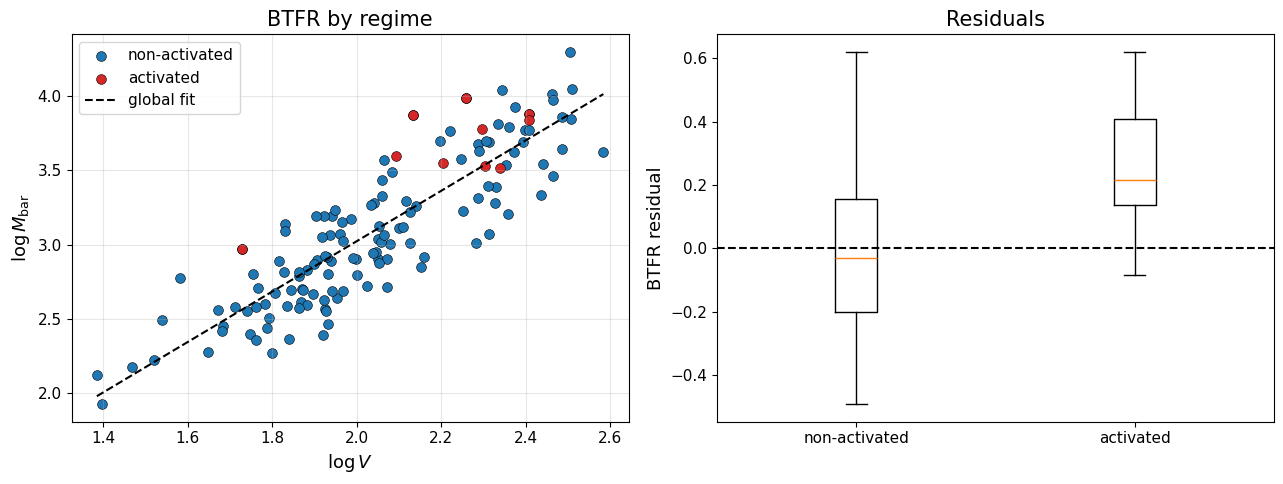

In [14]:
# =========================================================
# BTFR direkt aus df_core erzeugen (robust)
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Pfade
# =========================================================
BASE = "/content/drive/MyDrive/galaxy_field_project_2"
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(FIGDIR, exist_ok=True)

# =========================================================
# 2. Daten laden
# =========================================================
core_path = os.path.join(BASE, "df_core.csv")
thr_path  = os.path.join(BASE, "activation_threshold_analysis.csv")

if not os.path.exists(core_path):
    core_path = "/content/df_core.csv"
if not os.path.exists(thr_path):
    thr_path = "/content/activation_threshold_analysis.csv"

df_core = pd.read_csv(core_path)
thr = pd.read_csv(thr_path)

print("df_core:", df_core.shape)
print("thr:", thr.shape)

# =========================================================
# 3. BTFR-Daten pro Galaxie erzeugen
# =========================================================
groups = []

for gal, gdf in df_core.groupby("galaxy"):
    gdf = gdf.dropna(subset=["Vobs", "r"])
    if len(gdf) < 5:
        continue

    # Charakteristische Geschwindigkeit (max)
    Vchar = gdf["Vobs"].max()

    # Baryonischer Proxy (Summe)
    if "Vgas" in gdf.columns and "Vdisk" in gdf.columns:
        Mbar = np.sum(np.abs(gdf["Vgas"]) + np.abs(gdf["Vdisk"]))
    else:
        continue

    groups.append({
        "galaxy": gal,
        "Vchar": Vchar,
        "Mbar": Mbar
    })

btfr = pd.DataFrame(groups)

print("BTFR Tabelle:", btfr.shape)

# =========================================================
# 4. Regime hinzufügen
# =========================================================
reg = thr[["galaxy", "regime"]].drop_duplicates()
df = btfr.merge(reg, on="galaxy", how="inner")

print("Nach Merge:", df.shape)
print(df["regime"].value_counts())

# =========================================================
# 5. Logarithmen
# =========================================================
df = df[(df["Vchar"] > 0) & (df["Mbar"] > 0)].copy()

df["logV"] = np.log10(df["Vchar"])
df["logM"] = np.log10(df["Mbar"])

# =========================================================
# 6. Globaler Fit
# =========================================================
slope, intercept = np.polyfit(df["logV"], df["logM"], 1)

df["fit"] = slope * df["logV"] + intercept
df["resid"] = df["logM"] - df["fit"]

print("Slope:", slope)

# =========================================================
# 7. Plot
# =========================================================
color_map = {
    "non_activated": "#1f77b4",
    "activated": "#d62728"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Panel A: BTFR ----
ax = axes[0]

for reg_name in ["non_activated", "activated"]:
    sub = df[df["regime"] == reg_name]
    ax.scatter(
        sub["logV"], sub["logM"],
        s=50,
        color=color_map[reg_name],
        label=reg_name.replace("_", "-"),
        edgecolor="black",
        linewidth=0.4
    )

xx = np.linspace(df["logV"].min(), df["logV"].max(), 200)
yy = slope * xx + intercept

ax.plot(xx, yy, "k--", lw=1.5, label="global fit")

ax.set_xlabel(r"$\log V$")
ax.set_ylabel(r"$\log M_{\mathrm{bar}}$")
ax.set_title("BTFR by regime")
ax.grid(True, alpha=0.3)
ax.legend()

# ---- Panel B: Residuen ----
ax2 = axes[1]

data = [
    df[df["regime"] == "non_activated"]["resid"],
    df[df["regime"] == "activated"]["resid"]
]

ax2.boxplot(data, labels=["non-activated", "activated"], showfliers=False)
ax2.axhline(0, color="black", linestyle="--")

ax2.set_ylabel("BTFR residual")
ax2.set_title("Residuals")

plt.tight_layout()

# =========================================================
# 8. Speichern
# =========================================================
out = os.path.join(FIGDIR, "btfr_regimes.png")
plt.savefig(out, dpi=300, bbox_inches="tight")

print("Gespeichert:", out)

plt.show()

Gespeichert: /content/drive/MyDrive/galaxy_field_project_2/figures/dynamical_boost_clean.png


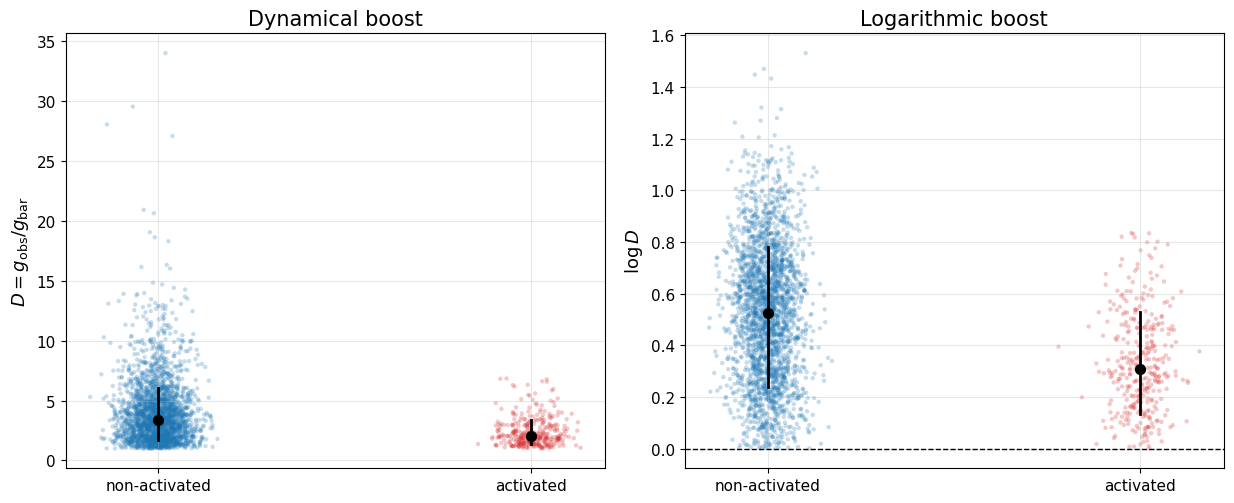

In [17]:
# =========================================================
# Dynamical Boost – clean version (scatter + median + spread)
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Pfade
# =========================================================
BASE = "/content/drive/MyDrive/galaxy_field_project_2"
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(FIGDIR, exist_ok=True)

# =========================================================
# 2. Daten laden
# =========================================================
core_path = os.path.join(BASE, "df_core.csv")
thr_path  = os.path.join(BASE, "activation_threshold_analysis.csv")

if not os.path.exists(core_path):
    core_path = "/content/df_core.csv"
if not os.path.exists(thr_path):
    thr_path = "/content/activation_threshold_analysis.csv"

df_core = pd.read_csv(core_path)
thr = pd.read_csv(thr_path)

# =========================================================
# 3. Merge
# =========================================================
reg = thr[["galaxy", "regime"]].drop_duplicates()
df = df_core.merge(reg, on="galaxy", how="inner")

df = df.dropna(subset=["gobs", "gbar", "regime"])
df = df[(df["gobs"] > 0) & (df["gbar"] > 0)].copy()

# =========================================================
# 4. Dynamical Boost
# =========================================================
df["D"] = df["gobs"] / df["gbar"]
df["logD"] = np.log10(df["D"])

# =========================================================
# 5. Plot-Stil
# =========================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

color_map = {
    "non_activated": "#1f77b4",
    "activated": "#d62728"
}

order = ["non_activated", "activated"]
labels = ["non-activated", "activated"]

# =========================================================
# 6. Figure
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

rng = np.random.default_rng(42)

# -------------------------------
# Panel A: D
# -------------------------------
ax = axes[0]

for i, reg_name in enumerate(order, start=1):
    vals = df[df["regime"] == reg_name]["D"].values

    # jittered points
    xj = rng.normal(i, 0.05, size=len(vals))
    ax.scatter(
        xj, vals,
        s=10,
        alpha=0.25,
        color=color_map[reg_name],
        edgecolors="none"
    )

    # Median
    med = np.median(vals)

    # 16–84% Bereich
    p16, p84 = np.percentile(vals, [16, 84])

    ax.plot([i, i], [p16, p84], color="black", lw=2)
    ax.scatter(i, med, color="black", s=50, zorder=5)

ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_ylabel(r"$D = g_{\mathrm{obs}} / g_{\mathrm{bar}}$")
ax.set_title("Dynamical boost")
ax.grid(True, alpha=0.3)

# -------------------------------
# Panel B: log D
# -------------------------------
ax2 = axes[1]

for i, reg_name in enumerate(order, start=1):
    vals = df[df["regime"] == reg_name]["logD"].values

    xj = rng.normal(i, 0.05, size=len(vals))
    ax2.scatter(
        xj, vals,
        s=10,
        alpha=0.25,
        color=color_map[reg_name],
        edgecolors="none"
    )

    med = np.median(vals)
    p16, p84 = np.percentile(vals, [16, 84])

    ax2.plot([i, i], [p16, p84], color="black", lw=2)
    ax2.scatter(i, med, color="black", s=50, zorder=5)

ax2.axhline(0, linestyle="--", color="black", linewidth=1)

ax2.set_xticks([1, 2])
ax2.set_xticklabels(labels)
ax2.set_ylabel(r"$\log D$")
ax2.set_title("Logarithmic boost")
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# =========================================================
# 7. Speichern
# =========================================================
out = os.path.join(FIGDIR, "dynamical_boost_clean.png")
plt.savefig(out, dpi=300, bbox_inches="tight")

print("Gespeichert:", out)

plt.show()

Gespeichert: /content/drive/MyDrive/galaxy_field_project_2/figures/regime_map.png


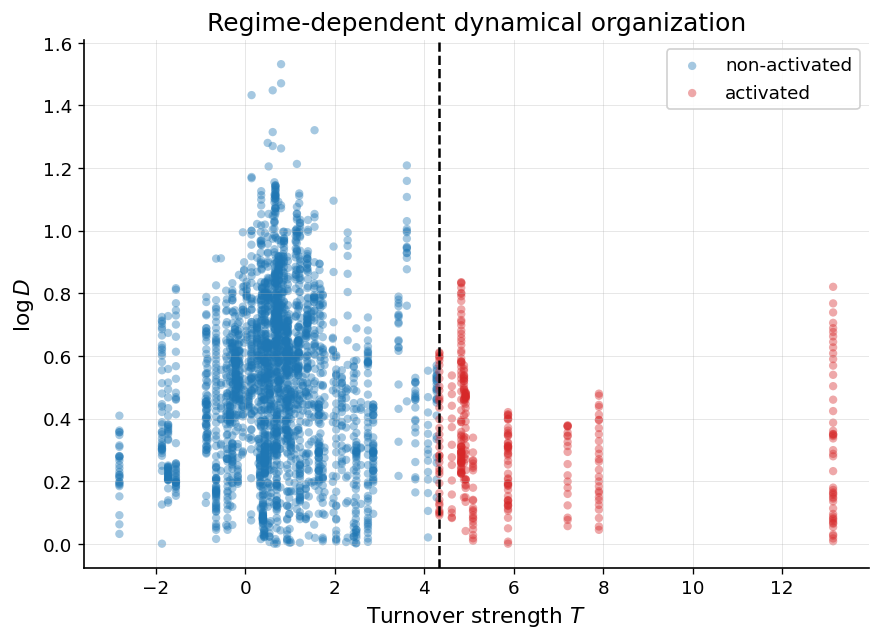

In [20]:
# =========================================================
# Regime Map: T vs D
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pfade
BASE = "/content/drive/MyDrive/galaxy_field_project_2"
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(FIGDIR, exist_ok=True)

# Daten laden
core_path = os.path.join(BASE, "df_core.csv")
thr_path  = os.path.join(BASE, "activation_threshold_analysis.csv")

if not os.path.exists(core_path):
    core_path = "/content/df_core.csv"
if not os.path.exists(thr_path):
    thr_path = "/content/activation_threshold_analysis.csv"

df_core = pd.read_csv(core_path)
thr = pd.read_csv(thr_path)

# Merge
reg = thr[["galaxy", "regime", "turnover"]].drop_duplicates()
df = df_core.merge(reg, on="galaxy", how="inner")

df = df.dropna(subset=["gobs", "gbar", "turnover"])
df = df[(df["gobs"] > 0) & (df["gbar"] > 0)].copy()

# Dynamical boost
df["D"] = df["gobs"] / df["gbar"]
df["logD"] = np.log10(df["D"])

# Plot
fig, ax = plt.subplots(figsize=(7.5, 5.5))

color_map = {
    "non_activated": "#1f77b4",
    "activated": "#d62728"
}

for reg_name in ["non_activated", "activated"]:
    sub = df[df["regime"] == reg_name]

    ax.scatter(
        sub["turnover"], sub["logD"],
        s=25,
        alpha=0.4,
        color=color_map[reg_name],
        label=reg_name.replace("_", "-"),
        edgecolor="none"
    )

# Tc Linie
Tc = thr[thr["regime"] == "activated"]["turnover"].min()

ax.axvline(Tc, linestyle="--", color="black", linewidth=1.5)

# Labels
ax.set_xlabel(r"Turnover strength $T$")
ax.set_ylabel(r"$\log D$")
ax.set_title("Regime-dependent dynamical organization")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# speichern
out = os.path.join(FIGDIR, "regime_map.png")
plt.savefig(out, dpi=300, bbox_inches="tight")

print("Gespeichert:", out)
plt.show()